<a href="https://colab.research.google.com/github/kingdragonlord/NLP-Text-Classification-with-Scikit-Learn-Pipelines/blob/main/NLP_Text_Classification_with_Scikit_Learn_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implementing NLP Pipelines with Sklearn

## Background Information. `sklearn` Data Transformers and Pipelines

Suppose that we have a set of text preprocessing steps that we need to apply sequentially to our dataset, prior to feature extraction and predictive modeling. In such cases, we can use a [`sklearn pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) to encapsulate all of the data transformation, feature extraction, and modeling steps into one object which has the same familiar interface as other classes in `sklearn`.

### `sklearn data Transformers`

https://scikit-learn.org/stable/data_transforms.html

Not to be confused with the `transformer` neural network architecture.

You can create your own `Transformer` classes that can be used with the rest of the `sklearn` ecosystem by subclassing `BaseEstimator` and `TransformerMixin`. In `sklearn`, transformer classes have two methods that need to be defined: `fit` and `transform`. Let's start with a simple example that lowercases and removes punctuation from text:

In [ ]:
# remove punctuation and lowercase
import string
from sklearn.base import BaseEstimator, TransformerMixin
import re

class TextCleaner(BaseEstimator, TransformerMixin):
  def __init__(self, remove_punct=True, lowercase=True):
    self.remove_punct = remove_punct
    self.lowercase = lowercase

  def fit(self, X, y=None): # nothing to do for this case
    return self

  def transform(self, X, y=None): # apply transformations to remove punctuation and lowercase
    cleaned_text = []
    for text in X:
      if self.lowercase:
        text = text.lower()
      if self.remove_punct:
        text = text.translate(str.maketrans('', '', string.punctuation))
      cleaned_text.append(text)
    return cleaned_text

Lemmatization Transformer example using nltk:

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')

class Lemmatizer(BaseEstimator, TransformerMixin):
  def __init__(self):
    self.lemmatizer = WordNetLemmatizer()

  def fit(self, X, y=None):
    return self

  def transform(self, X, y=None):
    lemmatized_text = []
    for text in X:
      tokens = word_tokenize(text)
      lemmatized_tokens = [self.lemmatizer.lemmatize(token) for token in tokens]
      lemmatized_text.append(' '.join(lemmatized_tokens))
    return lemmatized_text


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Remove stopwords, rare, or frequent words:

In [ ]:
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')

class WordFilter(BaseEstimator, TransformerMixin):
  def __init__(self, stop_words=None, remove_rare=True, remove_frequent=True, rare_threshold=1, freq_threshold=0.5):
    self.stop_words = stop_words if stop_words else set(stopwords.words('english'))
    self.remove_rare = remove_rare
    self.remove_frequent = remove_frequent
    self.rare_threshold = rare_threshold
    self.freq_threshold = freq_threshold

  def fit(self, X, y=None): # count the words, then define sets of rare and frequent words based on given thresholds
    all_words = ' '.join(X).split()
    word_counts = Counter(all_words)
    total_words = len(all_words)

    if self.remove_rare:
      self.rare_words = set([word for word, count in word_counts.items() if count <= self.rare_threshold])
    if self.remove_frequent:
      self.frequent_words = set([word for word, count in word_counts.items() if count / total_words > self.freq_threshold])

    return self

  def transform(self, X, y=None): # filter out stopwords, rare, and frequent words
    filtered_text = []

    for text in X:
      words = text.split()
      filtered_words = [word for word in words if word not in self.stop_words] # remove stop words

      if self.remove_rare:
        filtered_words = [word for word in filtered_words if word not in self.rare_words] # remove rare words

      if self.remove_frequent:
        filtered_words = [word for word in filtered_words if word not in self.frequent_words] # remove frequent words

      filtered_text.append(' '.join(filtered_words)) # join filtered words to form the result

    return filtered_text

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Substitute text based on a regular expression:

In [ ]:
import re

class RegexSubstitutor(BaseEstimator, TransformerMixin):
  def __init__(self, pattern, repl):
    self.pattern = pattern
    self.repl = repl

  def fit(self, X, y=None):
    return self

  def transform(self, X, y=None):
    substituted_text = [re.sub(self.pattern, self.repl, text) for text in X]
    return substituted_text

### Pipelines

In `sklearn`, a [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) allows you to chain together multiple steps in a machine learning workflow, such as data preprocessing, feature extraction, and model training. Pipelines simplify the process by enabling you to organize the workflow as a sequence of transformations, ending with a final estimator (e.g., a classifier or regressor).

Each step in the pipeline is applied in sequence, where the output of one step is the input to the next. Pipelines can be used directly with cross-validation methods like GridSearchCV and RandomizedSearchCV, making hyperparameter tuning easier for complicated workflows that involve multiple sequential steps. `sklearn` allows you to mix and match different transformers and estimators, making the pipeline reusable and flexible for various tasks.

## Task Description: Document Classification

The code below will download the dataset for this task. The "20 newsgroups" dataset comprises around 18000 newsgroups posts on 20 topics. The goal here is to create a machine learning model that is capable of classifying new incoming text into one of the corresponding groups/categories.

In [ ]:
# Download the 20 news group dataset for select categories
from sklearn.datasets import fetch_20newsgroups

categories = ["comp.graphics", "sci.electronics", "sci.space", 'misc.forsale', 'rec.sport.baseball']
newsgroups = fetch_20newsgroups(
    remove=("headers", "footers", "quotes"),
    subset='all',
    categories=categories,
    shuffle=True,
    random_state=42
)
documents = newsgroups.data
labels = newsgroups.target

Let's view some of these sampels to get an understanding of the dataset:

In [ ]:
n_samples = 5
for i, (document, label) in enumerate(zip(documents[:n_samples], labels[:n_samples])):
  print(f"{'-'*50}\nDocument {i}\n{'-'*50}\n{document}\n\nLabel: {newsgroups.target_names[label]}\n")

--------------------------------------------------
Document 0
--------------------------------------------------



Ok, here could be the first question or answer or something:

Q: I want to copyprotect a program I wrote.  How should I do it?
A: You would be wise not to copyprotect that program.  You see, those 
   people that wants to get a cracked copy of your program will go to 
   various length to crack your program, and some of those crackers 
   are good, and know the common tricks.
   So, the copy protection wouldn't stop those.
   Ok, then.  What about legitimate users?  Copy protection can be a hassle
   for legitimate users, and can hinder them in their work, expecially
   if there is some "key" item that can get lost.
   So, the copy protection wouldn't help much of the legitimate users, but
   would make life somewhat of a misery for them.



(This is my opinion, and I speak as a legitimate user :-)
You are of course free to have your opinion about this subject....




Lab

 This is an example of *text classification*, a fundamental task in NLP. Some of the other examples we have discussed in class are special cases of text classification, such as spam detection and sentiment analysis.

Text classification is very general, commonly used, and has a wide range of applications in various fields:
* Spam Detection
* Sentiment Analysis (an example of this in practice is Brand Monitoring on social media)
* Language and Author Detection
* Customer support ticket categorization (automatically route incoming requests to the appropriate department/category)
* Content moderation (automatically flagging whether content is inappropriate, harmful, etc.)
* Product Categorization in E-commerce (classifiy products into specific categories based on their description)
* Document/Topic Classification
* Clinical Diagnostic Systems (e.g. categorize clinical notes based on disease types; predict patient diagnosis from doctor's notes)
* And more!



### Instructions

Split the dataset into training, test, and validation splits:

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(documents, labels, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

Create at least three text preprocessing pipelines that combines two or more text preprocessing steps. You can use variants of any of the transformer classes listed above or create your own. For some inspiration for other text preprocessing techniques, refer to https://www.kaggle.com/code/sudalairajkumar/getting-started-with-text-preprocessing#Removal-of-stopwords .

In [ ]:
from sklearn.pipeline import Pipeline

preproc_pipe1 = Pipeline([
    ('cleaner', TextCleaner(remove_punct=True, lowercase=True)),
    ('lemmatizer', Lemmatizer())
])

preproc_pipe2 = Pipeline([
    ('cleaner', TextCleaner(remove_punct=True, lowercase=True)),
    ('word_filter', WordFilter(remove_rare=True, remove_frequent=True))
])

preproc_pipe3 = Pipeline([
    ('cleaner', TextCleaner(remove_punct=True, lowercase=True)),
    ('regex_sub', RegexSubstitutor(pattern=r'\d+', repl='NUM')),
    ('word_filter', WordFilter(remove_rare=True, remove_frequent=True))
])

Now create end-to-end pipelines that combine the preprocessing pipelines with a `TfidfVectorizer` and a classification model. You can experiment with different models if desired. Use word_tokenize from nltk as the `TfidfVectorizer's` tokenization scheme. Take care to disable relevant default parameters in the `TfidfVectorizer` depending on your text preprocessing strategy (e.g. parameters for lowercasing, stopword removal, etc).

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords


stop_words_nltk = stopwords.words('english')

full_pipe1 = Pipeline([
    ('preprocessing', preproc_pipe1),
    ('tfidf', TfidfVectorizer(
        tokenizer=word_tokenize,
        lowercase=False,
        stop_words=stop_words_nltk,
        token_pattern=None
    )),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

full_pipe2 = Pipeline([
    ('preprocessing', preproc_pipe2),
    ('tfidf', TfidfVectorizer(
        tokenizer=word_tokenize,
        lowercase=False,
        stop_words=None,
        token_pattern=None
    )),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

full_pipe3 = Pipeline([
    ('preprocessing', preproc_pipe3),
    ('tfidf', TfidfVectorizer(
        tokenizer=word_tokenize,
        lowercase=False,
        stop_words=None,
        token_pattern=None
    )),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])


Fit the end-to-end pipeline on the training set, then use the fitted pipeline to make predictions on the validation set.

*Note*: If you get a warning regarding `token_pattern`, you can resolve the warning by explicitly setting `token_pattern=None` in the `TfidfVectorizer` constructor above. It should work though regardless.

In [ ]:
from sklearn.metrics import accuracy_score

# Fit all pipelines on the training data
full_pipe1.fit(X_train, y_train)
full_pipe2.fit(X_train, y_train)
full_pipe3.fit(X_train, y_train)

# Make predictions on validation set
val_preds1 = full_pipe1.predict(X_val)
val_preds2 = full_pipe2.predict(X_val)
val_preds3 = full_pipe3.predict(X_val)



/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'could', 'might', 'must', "n't", 'need', 'sha', 'wo', 'would'] not in stop_words.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Use the fitted pipelines to make predictions on the validation set.

In [ ]:
# Optional: Calculate validation accuracy
val_acc1 = accuracy_score(y_val, val_preds1)
val_acc2 = accuracy_score(y_val, val_preds2)
val_acc3 = accuracy_score(y_val, val_preds3)

print(f"Validation Accuracy (Pipeline 1): {val_acc1:.3f}")
print(f"Validation Accuracy (Pipeline 2): {val_acc2:.3f}")
print(f"Validation Accuracy (Pipeline 3): {val_acc3:.3f}")

Validation Accuracy (Pipeline 1): 0.866
Validation Accuracy (Pipeline 2): 0.867
Validation Accuracy (Pipeline 3): 0.848


Evaluate your models/pipelines on the validation set.

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Evaluation Results for Pipeline 1
Accuracy: 0.866

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       184
           1       0.88      0.86      0.87       191
           2       0.85      0.91      0.88       197
           3       0.81      0.80      0.81       191
           4       0.93      0.86      0.89       220

    accuracy                           0.87       983
   macro avg       0.87      0.87      0.86       983
weighted avg       0.87      0.87      0.87       983



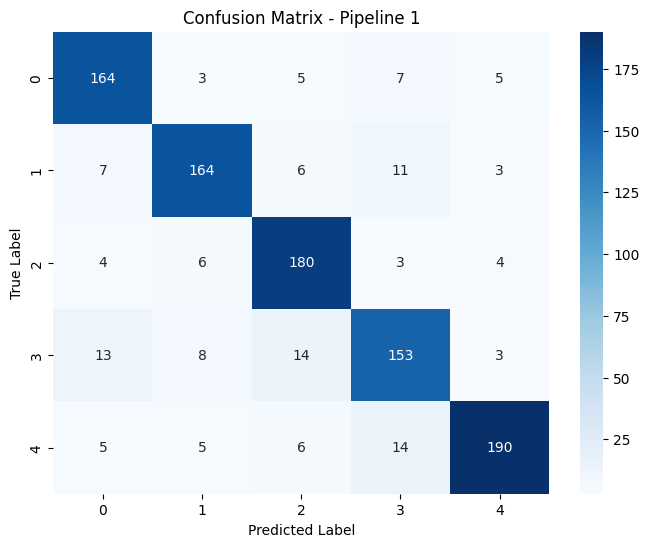

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Evaluation Results for Pipeline 2
Accuracy: 0.867

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       184
           1       0.91      0.86      0.88       191
           2       0.85      0.92      0.89       197
           3       0.80      0.81      0.80       191
           4       0.93      0.87      0.90       220

    accuracy                           0.87       983
   macro avg       0.87      0.87      0.87       983
weighted avg       0.87      0.87      0.87       983



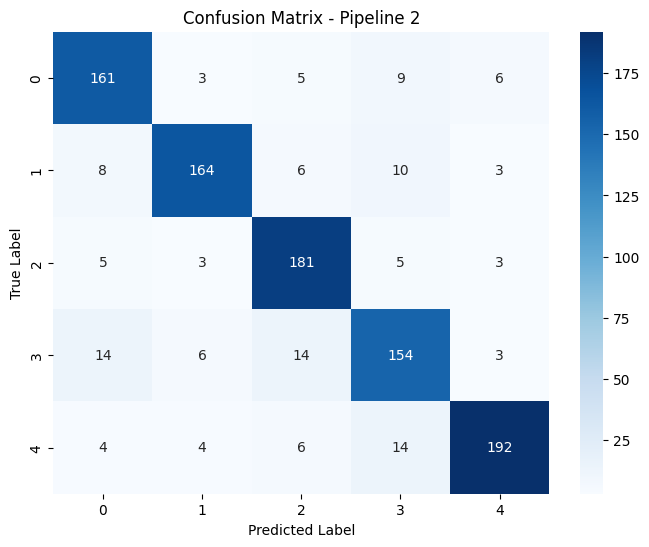

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Evaluation Results for Pipeline 3
Accuracy: 0.848

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       184
           1       0.86      0.85      0.86       191
           2       0.92      0.85      0.88       197
           3       0.80      0.77      0.79       191
           4       0.84      0.88      0.86       220

    accuracy                           0.85       983
   macro avg       0.85      0.85      0.85       983
weighted avg       0.85      0.85      0.85       983



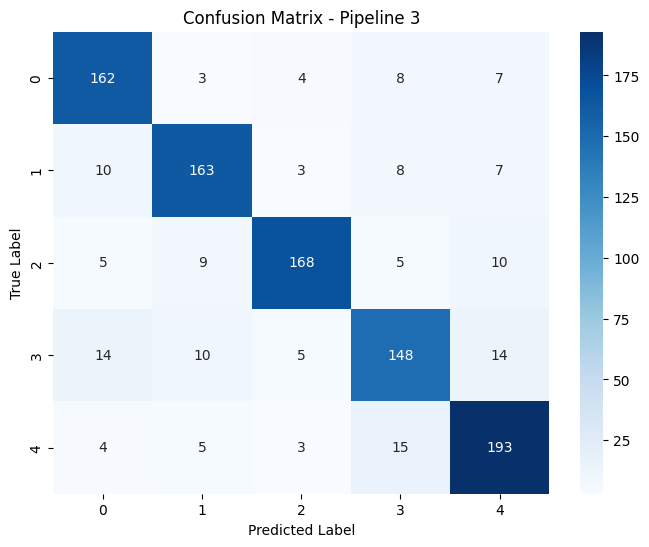


Model Comparison Summary:
Name         | Accuracy | Precision | Recall | F1-score
Pipeline 1   | 0.866   | 0.865    | 0.866 | 0.865
Pipeline 2   | 0.867   | 0.867    | 0.866 | 0.866
Pipeline 3   | 0.848   | 0.849    | 0.848 | 0.848


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(pipeline, X_val, y_val, name):
    # Generate predictions
    y_pred = pipeline.predict(X_val)

    # Calculate metrics
    accuracy = accuracy_score(y_val, y_pred)
    report = classification_report(y_val, y_pred, output_dict=True)

    # Print results
    print(f"\n{'='*40}")
    print(f"Evaluation Results for {name}")
    print(f"{'='*40}")
    print(f"Accuracy: {accuracy:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))

    # Plot confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=pipeline.classes_,
                yticklabels=pipeline.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Return metrics for comparison
    return {
        'name': name,
        'accuracy': accuracy,
        'precision': report['macro avg']['precision'],
        'recall': report['macro avg']['recall'],
        'f1': report['macro avg']['f1-score']
    }

# Evaluate all pipelines
results = []
for pipe, name in [(full_pipe1, 'Pipeline 1'),
                   (full_pipe2, 'Pipeline 2'),
                   (full_pipe3, 'Pipeline 3')]:
    results.append(evaluate_model(pipe, X_val, y_val, name))

# Compare model performances
print("\nModel Comparison Summary:")
print(f"{'Name':<12} | {'Accuracy':<7} | {'Precision':<8} | {'Recall':<6} | {'F1-score':<6}")
for res in results:
    print(f"{res['name']:<12} | {res['accuracy']:.3f}   | {res['precision']:.3f}    | {res['recall']:.3f} | {res['f1']:.3f}")


Experiment with a few different settings of pre-processing related hyperparameters by manually adjusting them above and rerunning the last several cells. Describe any experimentation or changes you make based on your findings below:

In [ ]:
# Adjust WordFilter thresholds
preproc_pipe2_v2 = Pipeline([
    ('cleaner', TextCleaner()),
    ('word_filter', WordFilter(
        remove_rare=True,
        remove_frequent=True,
        rare_threshold=3,  # Changed from 1
        freq_threshold=0.7  # Changed from 0.5
    ))
])

# Different regex pattern
preproc_pipe3_v2 = Pipeline([
    ('cleaner', TextCleaner()),
    ('regex_sub', RegexSubstitutor(pattern=r'\b\d+\w*\b', repl='NUM')),  # More comprehensive number detection
    ('word_filter', WordFilter()
)])

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Evaluation Results for Pipeline 2 v2
Accuracy: 0.862

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       184
           1       0.91      0.85      0.88       191
           2       0.85      0.91      0.88       197
           3       0.80      0.80      0.80       191
           4       0.92      0.87      0.89       220

    accuracy                           0.86       983
   macro avg       0.86      0.86      0.86       983
weighted avg       0.86      0.86      0.86       983



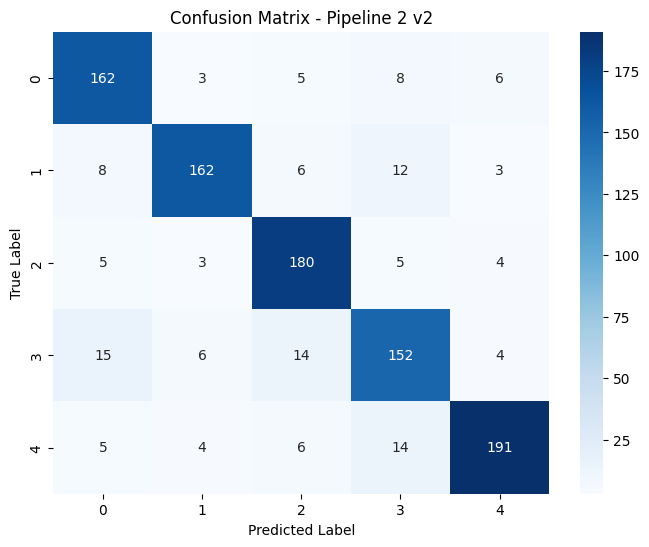

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Evaluation Results for Pipeline 3 v2
Accuracy: 0.843

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       184
           1       0.87      0.85      0.86       191
           2       0.92      0.86      0.89       197
           3       0.78      0.76      0.77       191
           4       0.84      0.88      0.86       220

    accuracy                           0.84       983
   macro avg       0.84      0.84      0.84       983
weighted avg       0.84      0.84      0.84       983



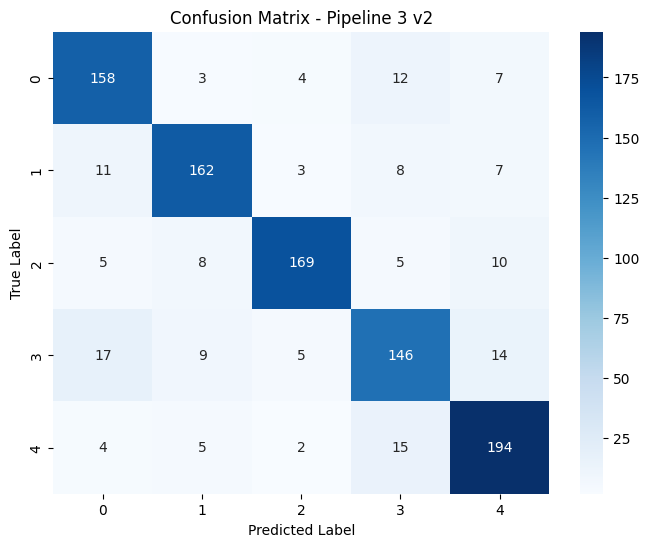


Final Model Comparison:
Name         | Accuracy | Precision | Recall | F1-score
Pipeline 1   | 0.866   | 0.865    | 0.866 | 0.865
Pipeline 2   | 0.867   | 0.867    | 0.866 | 0.866
Pipeline 3   | 0.848   | 0.849    | 0.848 | 0.848
Pipeline 2 v2 | 0.862   | 0.862    | 0.861 | 0.861
Pipeline 3 v2 | 0.843   | 0.844    | 0.842 | 0.843


In [ ]:
# 1. Create new full pipelines with modified preprocessing
full_pipe2_v2 = Pipeline([
    ('preprocessing', preproc_pipe2_v2),
    ('tfidf', TfidfVectorizer(
        tokenizer=word_tokenize,
        lowercase=False,
        stop_words=None,
        token_pattern=None
    )),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

full_pipe3_v2 = Pipeline([
    ('preprocessing', preproc_pipe3_v2),
    ('tfidf', TfidfVectorizer(
        tokenizer=word_tokenize,
        lowercase=False,
        stop_words=None,
        token_pattern=None
    )),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 2. Fit and evaluate the new versions
new_results = []
for pipe, name in [(full_pipe2_v2, 'Pipeline 2 v2'),
                   (full_pipe3_v2, 'Pipeline 3 v2')]:
    pipe.fit(X_train, y_train)  # Train on the same training data
    new_results.append(evaluate_model(pipe, X_val, y_val, name))

# 3. Compare with original results (combine both lists)
all_results = results + new_results

# Print comparison table
print("\nFinal Model Comparison:")
print(f"{'Name':<12} | {'Accuracy':<7} | {'Precision':<8} | {'Recall':<6} | {'F1-score':<6}")
for res in all_results:
    print(f"{res['name']:<12} | {res['accuracy']:.3f}   | {res['precision']:.3f}    | {res['recall']:.3f} | {res['f1']:.3f}")


I manually adjusted some of the parameters in pipeline 2 and 3. For pipeline 2 i tried a variety of different settings and got results in the same range but nothing significant. For pipeline 3 I added a better number detection and got worse results.

Perform hyperparameter optimization using RandomizedSearchCV. Use at least 3 different classification models in the cross validation.

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instanc


Best Parameters: {'classifier': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42), 'classifier__C': 1.7583640270008525, 'classifier__penalty': 'l2', 'preprocessing__word_filter__freq_threshold': 0.2812901539863683, 'preprocessing__word_filter__rare_threshold': 9, 'tfidf__max_features': 4988, 'tfidf__min_df': 4, 'tfidf__ngram_range': (1, 3), 'tfidf__sublinear_tf': False}
Best Validation Score: 0.966


/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Evaluation Results for Best Model from Search
Accuracy: 0.860

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       184
           1       0.91      0.86      0.89       191
           2       0.86      0.93      0.89       197
           3       0.80      0.78      0.79       191
           4       0.91      0.86      0.88       220

    accuracy                           0.86       983
   macro avg       0.86      0.86      0.86       983
weighted avg       0.86      0.86      0.86       983



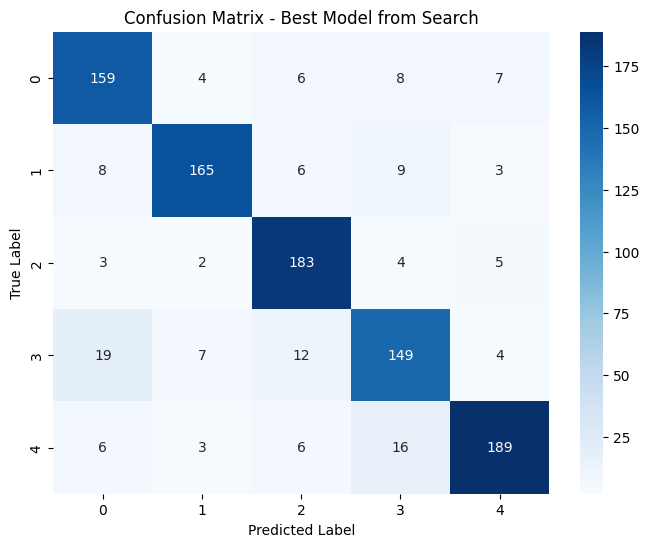

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import loguniform, randint, uniform
import numpy as np

# Define base_pipe
base_pipe = Pipeline([  # Define base_pipe before using it
    ('preprocessing', preproc_pipe2),  # You can choose any of your preprocessing pipelines
    ('tfidf', TfidfVectorizer(
        tokenizer=word_tokenize,
        lowercase=False,
        stop_words=None,
        token_pattern=None
    )),
    ('classifier', LogisticRegression()) # Placeholder for the classifier
])
# More focused parameter distributions
param_dist = [
    {  # Logistic Regression - Narrower ranges with domain knowledge
        'classifier': [LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')],
        'classifier__C': loguniform(1e-2, 1e2),  # Reduced range from original 1e-4-1e4
        'classifier__penalty': ['l2'],  # l1 often hurts performance with text data
        'tfidf__max_features': randint(500, 5000),  # Increased upper bound
        'tfidf__ngram_range': [(1,1), (1,2), (1,3)],
        'tfidf__sublinear_tf': [True, False],
        'preprocessing__word_filter__rare_threshold': randint(3, 15),  # Higher thresholds
        'preprocessing__word_filter__freq_threshold': uniform(0.05, 0.3),  # Lower ceiling
        'tfidf__min_df': randint(2, 5)  # New parameter to add
    },
    {  # SVM - Optimized for text data
        'classifier': [SVC(random_state=42, class_weight='balanced')],
        'classifier__C': loguniform(0.1, 10),
        'classifier__kernel': ['linear'],  # Focus on linear for high-dim text data
        'classifier__gamma': ['scale'],  # Remove 'auto' which is deprecated
        'tfidf__max_features': randint(1000, 10000),
        'tfidf__ngram_range': [(1,1), (1,2)],
        'tfidf__norm': ['l1', 'l2'],
        'preprocessing__word_filter__rare_threshold': randint(5, 20)
    },
    {  # Random Forest - Adjusted for better convergence
        'classifier': [RandomForestClassifier(random_state=42, class_weight='balanced_subsample')],
        'classifier__n_estimators': [200, 300, 400],  # Fixed values better than randint
        'classifier__max_depth': [None, 30, 50],  # Deeper trees
        'classifier__min_samples_split': randint(2, 5),
        'tfidf__max_features': randint(2000, 10000),
        'tfidf__binary': [True, False],
        'preprocessing__word_filter__freq_threshold': uniform(0.01, 0.2)
    },
    {  # Add SGDClassifier as it often works well with text
        'classifier': [SGDClassifier(random_state=42, loss='modified_huber')],
        'classifier__alpha': loguniform(1e-5, 1e-2),
        'classifier__penalty': ['l2', 'elasticnet'],
        'tfidf__max_features': randint(1000, 20000),
        'tfidf__ngram_range': [(1,2), (1,3)],
        'preprocessing__word_filter__rare_threshold': randint(1, 5)
    }
]

# Configure RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=base_pipe,
    param_distributions=param_dist,
    n_iter=77,  # Number of parameter settings to sample
    scoring='roc_auc_ovr',  # Can change to accuracy or other metrics
    n_jobs=1,
    cv=5,
    random_state=42
)

# Run the search
random_search.fit(X_train, y_train)

# Get best model and results
best_pipe = random_search.best_estimator_
print(f"\nBest Parameters: {random_search.best_params_}")
print(f"Best Validation Score: {random_search.best_score_:.3f}")

# Evaluate on validation set
best_val_metrics = evaluate_model(best_pipe, X_val, y_val, "Best Model from Search")


/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Evaluation Results for Optimized Model
Accuracy: 0.860

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       184
           1       0.91      0.86      0.89       191
           2       0.86      0.93      0.89       197
           3       0.80      0.78      0.79       191
           4       0.91      0.86      0.88       220

    accuracy                           0.86       983
   macro avg       0.86      0.86      0.86       983
weighted avg       0.86      0.86      0.86       983



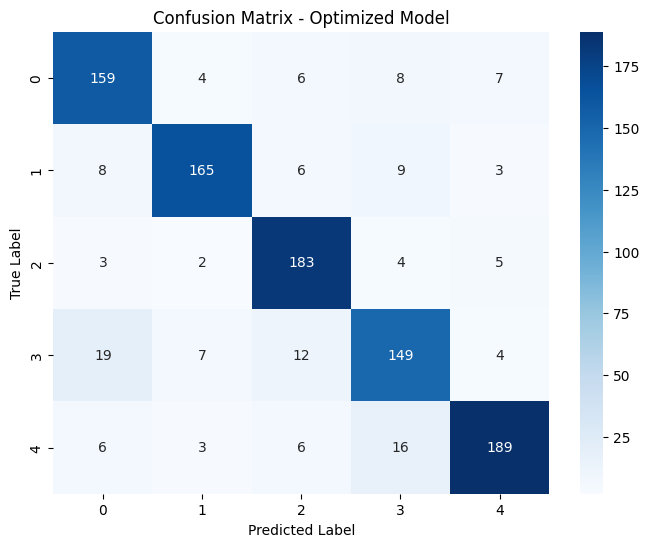


Optimized Model Parameters:
classifier: LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
classifier__C: 1.7583640270008525
classifier__penalty: l2
preprocessing__word_filter__freq_threshold: 0.2812901539863683
preprocessing__word_filter__rare_threshold: 9
tfidf__max_features: 4988
tfidf__min_df: 4
tfidf__ngram_range: (1, 3)
tfidf__sublinear_tf: False

Final Model Comparison:


,name,accuracy,precision,recall,f1
1,Pipeline 2,0.867,0.867,0.866,0.866
0,Pipeline 1,0.866,0.865,0.866,0.865
3,Pipeline 2 v2,0.862,0.862,0.861,0.861
5,Optimized Model,0.860,0.859,0.859,0.858
2,Pipeline 3,0.848,0.849,0.848,0.848
4,Pipeline 3 v2,0.843,0.844,0.842,0.843


<ipython-input-41-728df1f04c3d>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='f1', y='name', data=results_df, palette='viridis')


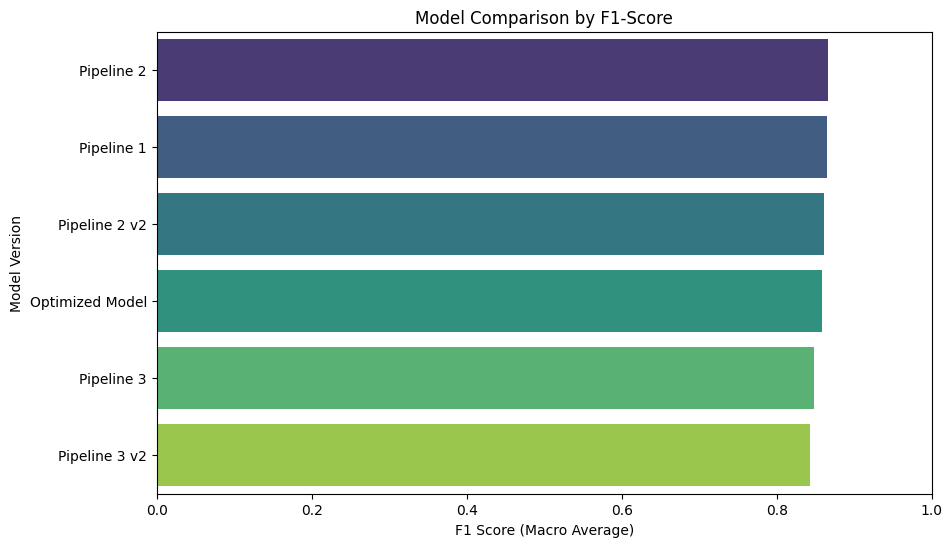

In [ ]:
# Evaluate the best model from RandomizedSearchCV
optimized_metrics = evaluate_model(best_pipe, X_val, y_val, "Optimized Model")

# Get the best parameters for reference
optimized_params = random_search.best_params_
print("\nOptimized Model Parameters:")
for key, value in optimized_params.items():
    print(f"{key}: {value}")

# Create comparison with original models
final_results = results + new_results + [optimized_metrics]

# Generate comparison table with sorting
import pandas as pd

# Convert results to DataFrame
results_df = pd.DataFrame(final_results).sort_values('f1', ascending=False)

# Format the table
pd.options.display.float_format = '{:.3f}'.format
print("\nFinal Model Comparison:")
display(results_df[['name', 'accuracy', 'precision', 'recall', 'f1']])

# Visual comparison plot
plt.figure(figsize=(10, 6))
sns.barplot(x='f1', y='name', data=results_df, palette='viridis')
plt.title('Model Comparison by F1-Score')
plt.xlabel('F1 Score (Macro Average)')
plt.ylabel('Model Version')
plt.xlim(0, 1)
plt.show()


Once you are done making any desired adjustments to your model and/or configurations for text preprocessing, you are ready to do the final evaluation on the test set...

Evaluate your model on the test set and use your results to perform an error analysis for your best model/pipeline.

/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(



Evaluation Results for Optimized Model - Final Test
Accuracy: 0.851

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       187
           1       0.90      0.85      0.88       201
           2       0.84      0.95      0.90       211
           3       0.78      0.78      0.78       194
           4       0.87      0.79      0.83       190

    accuracy                           0.85       983
   macro avg       0.85      0.85      0.85       983
weighted avg       0.85      0.85      0.85       983



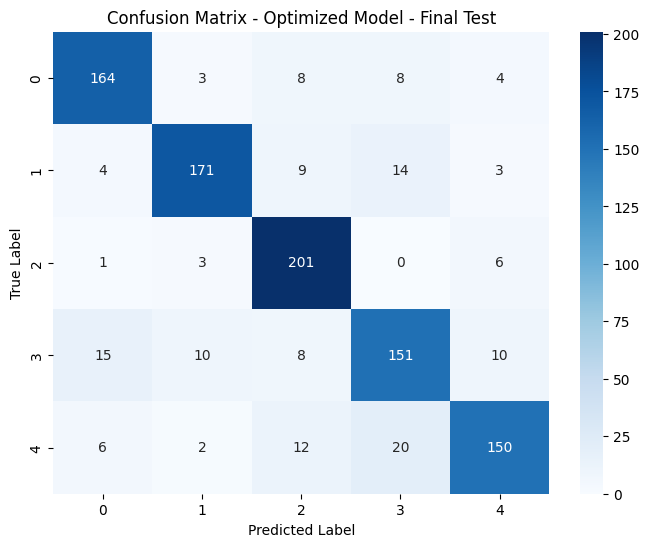


Final Test Set Performance:
• Accuracy: 0.851
• Precision (Macro): 0.852
• Recall (Macro): 0.850
• F1-Score (Macro): 0.850

Performance Comparison:
Validation F1: 0.858 → Test F1: 0.850
 F1: -0.009
Validation Accuracy: 0.860 → Test Accuracy: 0.851
 Accuracy: -0.008


In [ ]:
# Evaluate the optimized model on test data
final_test_metrics = evaluate_model(best_pipe, X_test, y_test, "Optimized Model - Final Test")

# Print key metrics in a clean format
print("\n\033[1mFinal Test Set Performance:\033[0m")
print(f"• Accuracy: {final_test_metrics['accuracy']:.3f}")
print(f"• Precision (Macro): {final_test_metrics['precision']:.3f}")
print(f"• Recall (Macro): {final_test_metrics['recall']:.3f}")
print(f"• F1-Score (Macro): {final_test_metrics['f1']:.3f}")

# Compare with validation performance
print("\n\033[1mPerformance Comparison:\033[0m")
print(f"Validation F1: {optimized_metrics['f1']:.3f} → Test F1: {final_test_metrics['f1']:.3f}")
print(f" F1: {final_test_metrics['f1'] - optimized_metrics['f1']:+.3f}")
print(f"Validation Accuracy: {optimized_metrics['accuracy']:.3f} → Test Accuracy: {final_test_metrics['accuracy']:.3f}")
print(f" Accuracy: {final_test_metrics['accuracy'] - optimized_metrics['accuracy']:+.3f}")

Summarize your experiments and discuss your findings.

A couple of the things I tried to get a better result was increase iterations which did not make a major difference in this example. I also tried optimizing to different scoring like accuracy and f1, but noticed that when evaluating on the test set the score differed quiet a bit (about 3% compared to 1%). When optimizing for roc_auc_ovr or (Receiver Operating Characteristic Area Under the Curve, which performs better for NLP) I received a much lower variance score in the test set than the score I received in the validation set.

At the end I received very similar results with the pre-processed pipelines as I did with the optimized pipeline. I think what would of helped in this is if I would of used diferrent and/or more prepocessing steps and then optimized those pipelines. It wasn't until I got about 2/3 complete that I realized that I needed to be more intentional about the preprocessing steps I choose at the beggining to get much improved results.

One thing to note was that pipeline 1 which had the least amount of preprocessing steps performed marginally better on the test set than all of the other pipelines.